In [6]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_pad_logs(file_path, arch_name):
    with open(file_path, 'r') as f:
        data = json.load(f)
    df = pd.json_normalize(data)
    df['architecture'] = arch_name
    
    if len(df) == 19:
        empty_row = pd.DataFrame(np.nan, index=[14], columns=df.columns)
        empty_row['architecture'] = arch_name
        df = pd.concat([df.iloc[:14], empty_row, df.iloc[14:]]).reset_index(drop=True)
    return df

# Load all 4 architectures
baseline_df = load_and_pad_logs('logs/telemetry_baseline_mistral-small3.2.json', 'Baseline')
spear_l32_df = load_and_pad_logs('logs/telemetry_SPEAR_llama3.2.json', 'SPEAR (Lla3.2 Router)')
spear_p35_df = load_and_pad_logs('logs/telemetry_SPEAR_phi3.5-3.8b.json', 'SPEAR (Phi-3.5 Router)')
spear_ge3_df = load_and_pad_logs('logs/telemetry_SPEAR_gemma3-4b.json', 'SPEAR (Gem3 Router)')

df = pd.concat([baseline_df, spear_ge3_df, spear_l32_df, spear_p35_df], ignore_index=True)

# Compute Metrics
critic_cols = [
    'async_critic_scores.rule_accuracy',
    'async_critic_scores.narrative_coherence',
    'async_critic_scores.npc_voice_consistency'
]
df['avg_critic_score'] = df[critic_cols].mean(axis=1)
df['score_per_1k'] = (df['avg_critic_score'] / df['total_tokens']) * 1000

# Color Palettes
arch_colors = {
    'Baseline': '#3498db',
    'SPEAR (Gem3 Router)': '#e74c3c',
    'SPEAR (Lla3.2 Router)': '#2ecc71',
    'SPEAR (Phi-3.5 Router)': '#9b59b6'
}

/tmp/ipykernel_3050/4273747452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


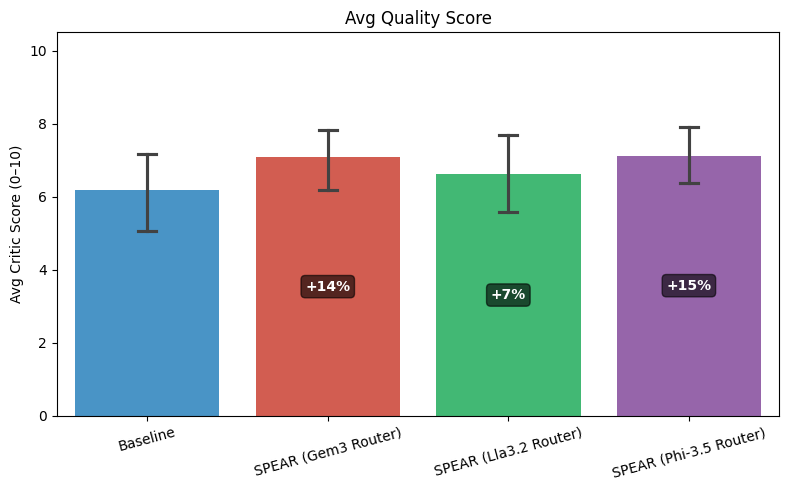

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x='architecture',
    y='avg_critic_score',
    data=df,
    palette=arch_colors,
    capsize=0.1,
    ax=ax
)

# --- Compute baseline mean ---
baseline_mean = df[df['architecture'] == 'Baseline']['avg_critic_score'].mean()

# --- Compute mean per architecture (same logic style as before) ---
stats = df.groupby('architecture')['avg_critic_score'].mean().reset_index()

# Ensure consistent order
arch_order = ['Baseline', 'SPEAR (Gem3 Router)', 'SPEAR (Lla3.2 Router)', 'SPEAR (Phi-3.5 Router)']
stats = stats.set_index('architecture').loc[arch_order].reset_index()

# --- Add % improvement annotations ---
for i, row in stats.iterrows():
    if row['architecture'] != 'Baseline':
        improvement = ((row['avg_critic_score'] - baseline_mean) / baseline_mean) * 100
        ax.text(
            i,
            row['avg_critic_score'] / 2,
            f'+{improvement:.0f}%',
            ha='center',
            va='center',
            fontweight='bold',
            fontsize=10,
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6)
        )

ax.set_title('Avg Quality Score')
ax.set_xlabel('')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3050/4083841089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


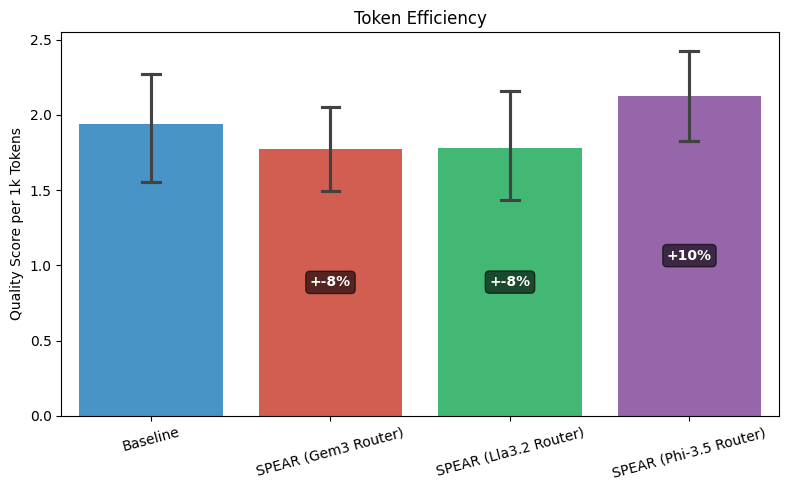

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x='architecture',
    y='score_per_1k',
    data=df,
    palette=arch_colors,
    capsize=0.1,
    ax=ax
)

# --- Compute baseline mean ---
baseline_mean = df[df['architecture'] == 'Baseline']['score_per_1k'].mean()

# --- Compute mean per architecture ---
stats = df.groupby('architecture')['score_per_1k'].mean().reset_index()

# Ensure consistent order
arch_order = ['Baseline', 'SPEAR (Gem3 Router)', 'SPEAR (Lla3.2 Router)', 'SPEAR (Phi-3.5 Router)']
stats = stats.set_index('architecture').loc[arch_order].reset_index()

# --- Add % improvement annotations ---
for i, row in stats.iterrows():
    if row['architecture'] != 'Baseline':
        improvement = ((row['score_per_1k'] - baseline_mean) / baseline_mean) * 100
        ax.text(
            i,
            row['score_per_1k'] / 2,
            f'+{improvement:.0f}%',
            ha='center',
            va='center',
            fontweight='bold',
            fontsize=10,
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6)
        )

ax.set_title('Token Efficiency')
ax.set_xlabel('')
ax.set_ylabel('Quality Score per 1k Tokens')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

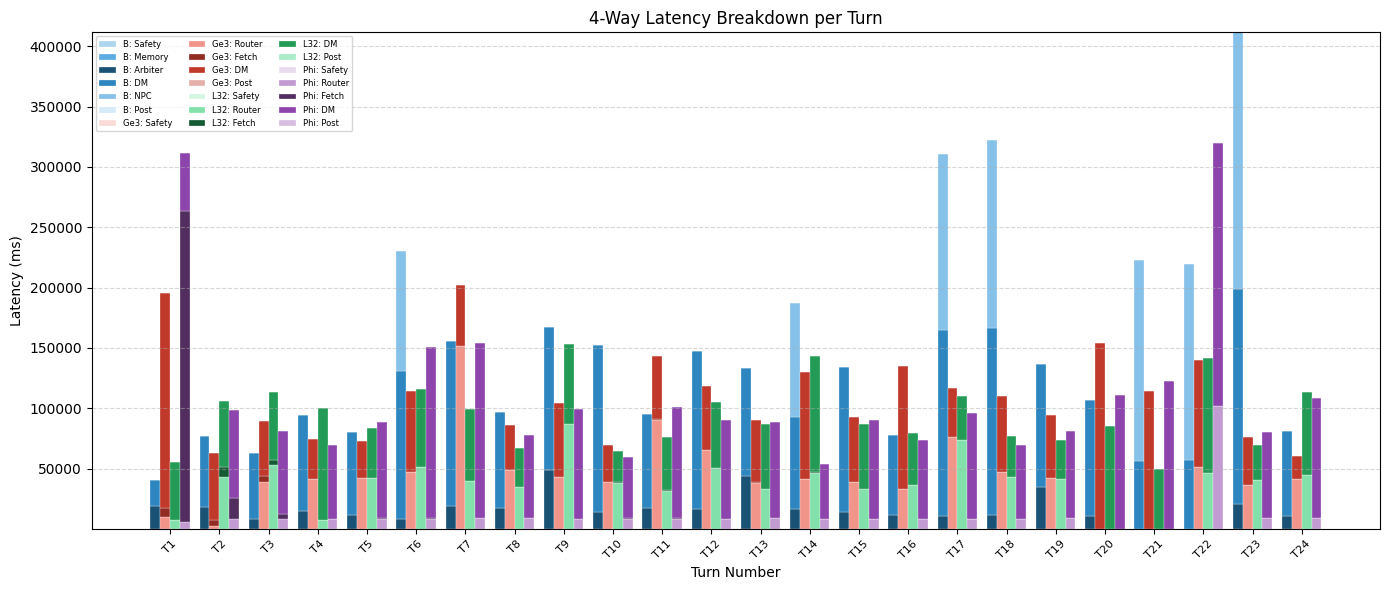

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

def extract_spear_comps(sub_df):
    return pd.DataFrame({
        'Safety':  sub_df['latency_breakdown.safety_filter_ms'].fillna(0),
        'Router':  sub_df['latency_breakdown.router_ms'].fillna(0),
        'Fetch':   sub_df['latency_breakdown.parallel_fetch_ms'].fillna(0),
        'DM':      sub_df['latency_breakdown.dm_ms'].fillna(0),
        'Post':    sub_df['latency_breakdown.post_processing_ms'].fillna(0),
    })

base_comps = pd.DataFrame({
    'B: Safety':  baseline_df['latency_breakdown.safety_ms'].fillna(0),
    'B: Memory':  baseline_df['latency_breakdown.memory_ms'].fillna(0),
    'B: Arbiter': baseline_df['latency_breakdown.arbiter_ms'].fillna(0),
    'B: DM':      baseline_df['latency_breakdown.dm_ms'].fillna(0),
    'B: NPC':     baseline_df['latency_breakdown.npc_agent_ms'].fillna(0),
    'B: Post':    baseline_df['latency_breakdown.post_processing_ms'].fillna(0),
})

ge3_comps = extract_spear_comps(spear_ge3_df)
l32_comps = extract_spear_comps(spear_l32_df)
phi_comps = extract_spear_comps(spear_p35_df)

c_base = ['#AED6F1', '#5DADE2', '#1A5276', '#2E86C1', '#85C1E9', '#D6EAF8']
c_ge3  = ['#FADBD8', '#F1948A', '#922B21', '#C0392B', '#E6B0AA']
c_l32  = ['#D5F5E3', '#82E0AA', '#145A32', '#239B56', '#ABEBC6']
c_phi  = ['#E8DAEF', '#C39BD3', '#512E5F', '#8E44AD', '#D7BDE2']

max_len = max(len(base_comps), len(ge3_comps), len(l32_comps), len(phi_comps))
x = np.arange(max_len)
width = 0.2

def plot_stack(ax, comps, offset, colors, prefix):
    bottom = np.zeros(len(comps))  # Use actual length
    for idx, col in enumerate(comps.columns):
        label = f"{prefix}: {col}" if "B:" not in col else col
        ax.bar(
            x + offset,
            comps[col],
            width,
            label=label,
            bottom=bottom,
            color=colors[idx],
            edgecolor='white',
            linewidth=0.2
        )
        bottom += comps[col].values

plot_stack(ax, base_comps, -0.3, c_base, "Base")
plot_stack(ax, ge3_comps,  -0.1, c_ge3,  "Ge3")
plot_stack(ax, l32_comps,   0.1, c_l32,  "L32")
plot_stack(ax, phi_comps,   0.3, c_phi,  "Phi")

ax.set_title('4-Way Latency Breakdown per Turn')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Latency (ms)')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(max_len)], rotation=45, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=6, ncol=3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3050/533764691.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


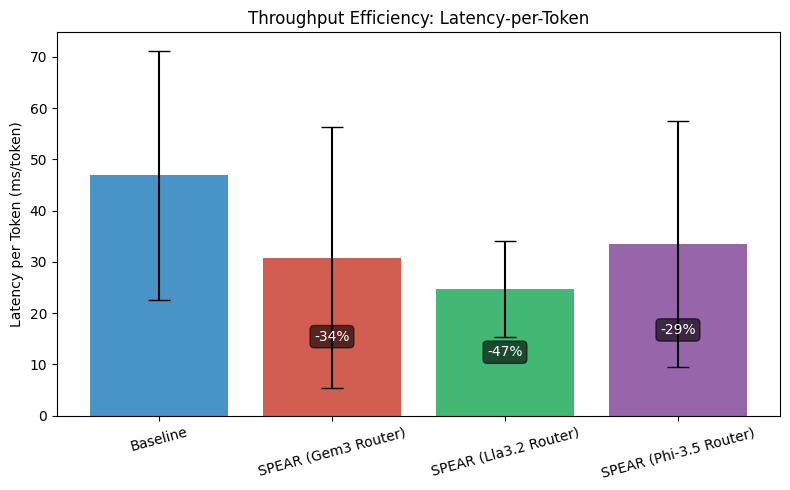

In [22]:
# Latency-per-Token Efficiency
df['latency_per_token'] = df['latency_ms'] / df['total_tokens']

fig, ax = plt.subplots(figsize=(8, 5))

# Compute stats
stats = df.groupby('architecture')['latency_per_token'].agg(['mean', 'std']).reset_index()
arch_order = ['Baseline', 'SPEAR (Gem3 Router)', 'SPEAR (Lla3.2 Router)', 'SPEAR (Phi-3.5 Router)']
stats = stats.set_index('architecture').loc[arch_order].reset_index()

# Seaborn barplot
sns.barplot(
    x='architecture',
    y='mean',
    data=stats,
    order=arch_order,
    palette=arch_colors,
    capsize=0.1,
    ax=ax
)

baseline_mean = stats.loc[stats['architecture'] == 'Baseline', 'mean'].values[0]

# Add error bars manually
ax.errorbar(
    x=range(len(stats)),
    y=stats['mean'],
    yerr=stats['std'],
    fmt='none',
    ecolor='black',
    capsize=8,
    linewidth=1.5
)

# Add % improvement
for i, row in stats.iterrows():
    if row['architecture'] != 'Baseline':
        improvement = ((baseline_mean - row['mean']) / baseline_mean) * 100
        ax.text(
            i,
            row['mean'] / 2,
            f"-{improvement:.0f}%",
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6)
        )

# Styling to match reference
ax.set_title('Throughput Efficiency: Latency-per-Token')
ax.set_xlabel('')
ax.set_ylabel('Latency per Token (ms/token)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

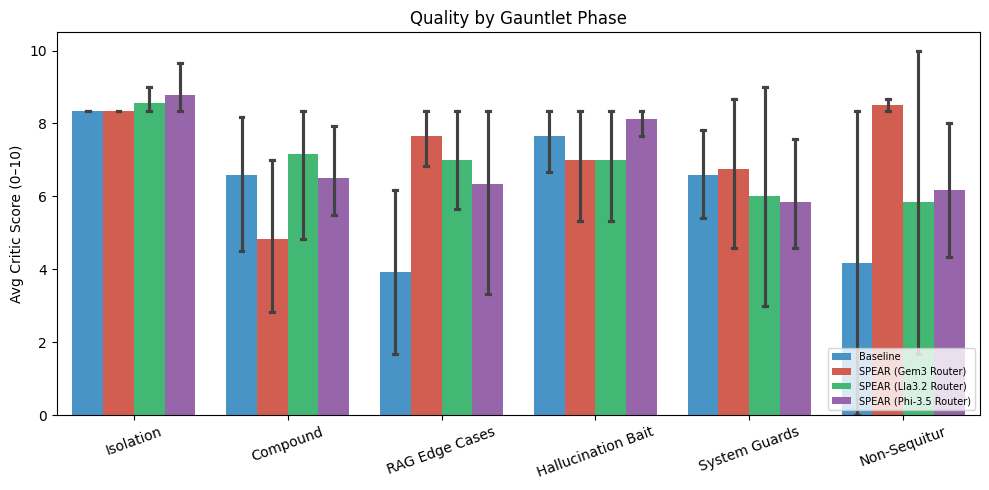

In [11]:
phase_labels = [
    'Isolation', 'Isolation', 'Isolation',
    'Compound', 'Compound', 'Compound', 'Compound',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'Hallucination Bait', 'Hallucination Bait', 'Hallucination Bait',
    'System Guards', 'System Guards', 'System Guards', 'System Guards',
    'Non-Sequitur', 'Non-Sequitur'
]

df['phase'] = df.groupby('architecture').cumcount().map(dict(enumerate(phase_labels)))

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='phase',
    y='avg_critic_score',
    hue='architecture',
    data=df,
    palette=arch_colors,
    capsize=0.1,
    ax=ax
)

ax.set_title('Quality by Gauntlet Phase')
ax.set_xlabel('')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

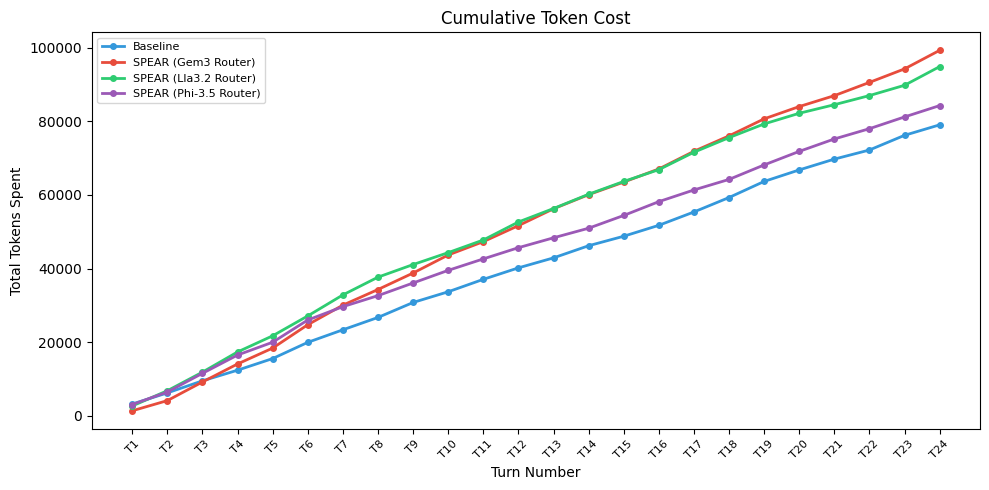

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for arch, color in arch_colors.items():
    subset = df[df['architecture'] == arch].reset_index(drop=True)
    cum_tokens = subset['total_tokens'].fillna(0).cumsum()
    ax.plot(
        range(len(cum_tokens)),
        cum_tokens,
        color=color,
        linewidth=2,
        label=arch,
        marker='o',
        markersize=4
    )

max_turns = df.groupby('architecture').size().iloc[0]  # Get actual turn count
x = np.arange(max_turns)
ax.set_title('Cumulative Token Cost')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Total Tokens Spent')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(max_turns)], rotation=45, fontsize=8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

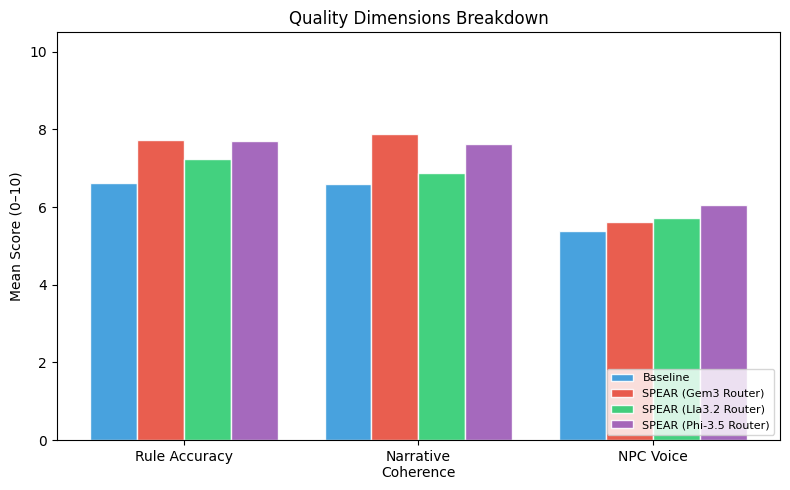

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

dims = [
    'async_critic_scores.rule_accuracy',
    'async_critic_scores.narrative_coherence',
    'async_critic_scores.npc_voice_consistency'
]

dim_labels = ['Rule Accuracy', 'Narrative\nCoherence', 'NPC Voice']
x_dim = np.arange(len(dims))
width_dim = 0.2

for i, (arch, color) in enumerate(arch_colors.items()):
    offset = (i - 1.5) * width_dim
    means = [df[df['architecture'] == arch][d].mean() for d in dims]
    
    ax.bar(
        x_dim + offset,
        means,
        width_dim,
        label=arch,
        color=color,
        alpha=0.9,
        edgecolor='white'
    )

ax.set_title('Quality Dimensions Breakdown')
ax.set_ylabel('Mean Score (0–10)')
ax.set_xticks(x_dim)
ax.set_xticklabels(dim_labels, fontsize=10)
ax.set_ylim(0, 10.5)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3050/3017800030.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3050/3017800030.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='architecture', y='score_per_1k', data=df, palette=arch_colors, capsize=0.1, ax=ax)


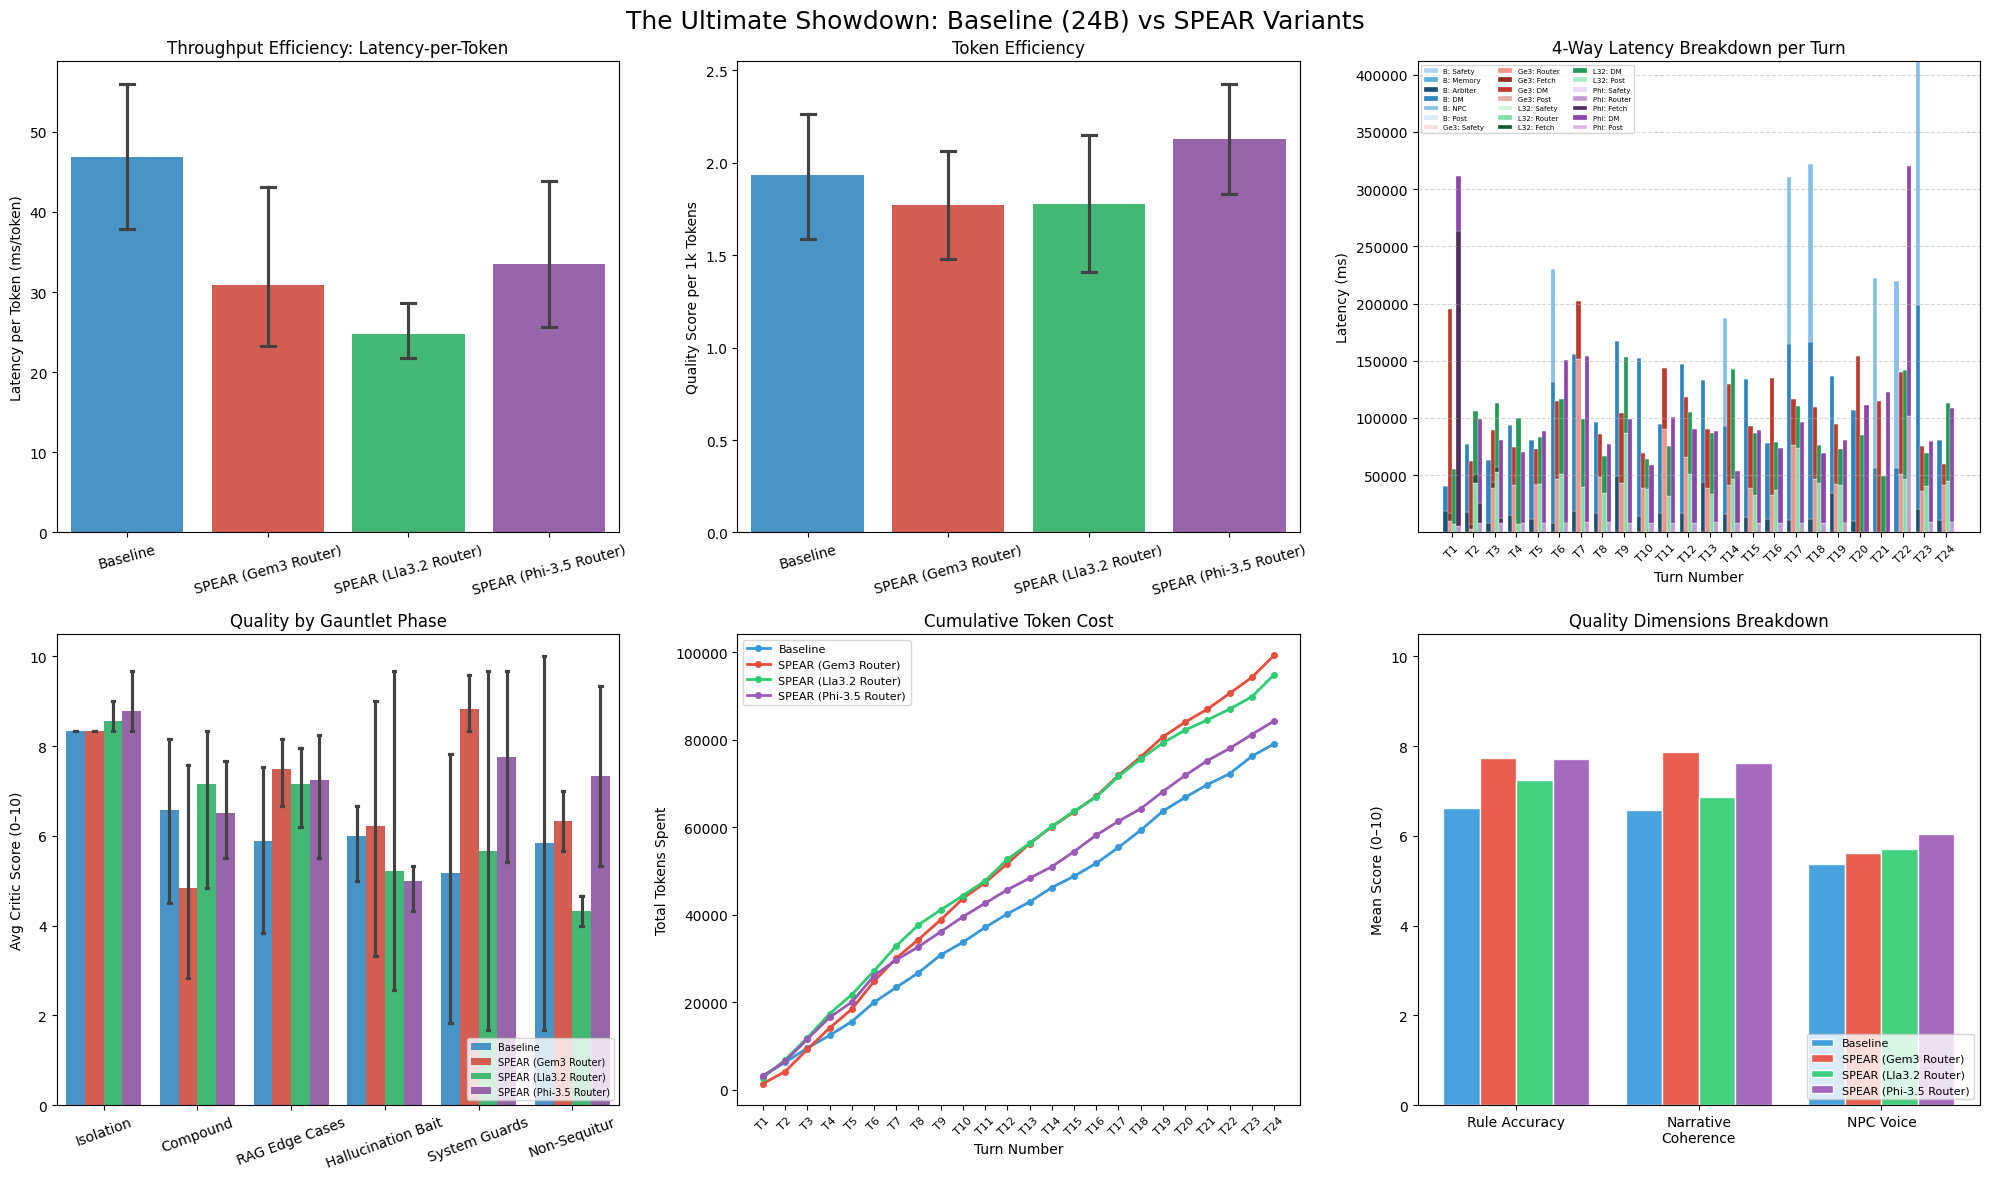

In [23]:
N_TURNS = max(len(baseline_df), len(spear_l32_df), len(spear_p35_df), len(spear_ge3_df))

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("The Ultimate Showdown: Baseline (24B) vs SPEAR Variants", fontsize=18)

# --- Latency-per-Token Efficiency ---
ax = axes[0, 0]

# Compute metric
df['latency_per_token'] = df['latency_ms'] / df['total_tokens']

# Barplot
sns.barplot(
    x='architecture',
    y='latency_per_token',
    data=df,
    palette=arch_colors,
    capsize=0.1,
    ax=ax
)

# Ensure consistent order
arch_order = ['Baseline', 'SPEAR (Gem3 Router)', 'SPEAR (Lla3.2 Router)', 'SPEAR (Phi-3.5 Router)']
stats = stats.set_index('architecture').loc[arch_order].reset_index()

ax.set_title('Throughput Efficiency: Latency-per-Token')
ax.set_xlabel('')
ax.set_ylabel('Latency per Token (ms/token)')
ax.tick_params(axis='x', rotation=15)

# --- Token Efficiency ---
ax = axes[0, 1]
sns.barplot(x='architecture', y='score_per_1k', data=df, palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Token Efficiency')
ax.set_xlabel('')
ax.set_ylabel('Quality Score per 1k Tokens')
ax.tick_params(axis='x', rotation=15)

# --- 4-Way Latency Breakdown per Turn ---
ax = axes[0, 2]

def extract_spear_comps(sub_df):
    return pd.DataFrame({
        'Safety':  sub_df['latency_breakdown.safety_filter_ms'].fillna(0).values,
        'Router':  sub_df['latency_breakdown.router_ms'].fillna(0).values,
        'Fetch':   sub_df['latency_breakdown.parallel_fetch_ms'].fillna(0).values,
        'DM':      sub_df['latency_breakdown.dm_ms'].fillna(0).values,
        'Post':    sub_df['latency_breakdown.post_processing_ms'].fillna(0).values,
    })

base_comps = pd.DataFrame({
    'B: Safety':  baseline_df['latency_breakdown.safety_ms'].fillna(0).values,
    'B: Memory':  baseline_df['latency_breakdown.memory_ms'].fillna(0).values,
    'B: Arbiter': baseline_df['latency_breakdown.arbiter_ms'].fillna(0).values,
    'B: DM':      baseline_df['latency_breakdown.dm_ms'].fillna(0).values,
    'B: NPC':     baseline_df['latency_breakdown.npc_agent_ms'].fillna(0).values,
    'B: Post':    baseline_df['latency_breakdown.post_processing_ms'].fillna(0).values,
})

ge3_comps = extract_spear_comps(spear_ge3_df)
l32_comps = extract_spear_comps(spear_l32_df)
phi_comps = extract_spear_comps(spear_p35_df)

# Specific Stack Colors to match their architectures
c_base = ['#AED6F1', '#5DADE2', '#1A5276', '#2E86C1', '#85C1E9', '#D6EAF8']
c_ge3  = ['#FADBD8', '#F1948A', '#922B21', '#C0392B', '#E6B0AA']
c_l32  = ['#D5F5E3', '#82E0AA', '#145A32', '#239B56', '#ABEBC6']
c_phi  = ['#E8DAEF', '#C39BD3', '#512E5F', '#8E44AD', '#D7BDE2']

x = np.arange(N_TURNS)
width = 0.2

def plot_stack(ax, comps, offset, colors, prefix, n_turns):
    bottom = np.zeros(n_turns)
    for idx, col in enumerate(comps.columns):
        label = col if col.startswith("B:") else f"{prefix}: {col}"
        ax.bar(x + offset, comps[col].fillna(0), width, label=label, bottom=bottom,
               color=colors[idx], edgecolor='white', linewidth=0.2)
        bottom += comps[col].fillna(0).values

plot_stack(ax, base_comps, -0.3, c_base, "Base", N_TURNS)
plot_stack(ax, ge3_comps,  -0.1, c_ge3,  "Ge3",  N_TURNS)
plot_stack(ax, l32_comps,   0.1, c_l32,  "L32",  N_TURNS)
plot_stack(ax, phi_comps,   0.3, c_phi,  "Phi",  N_TURNS)

ax.set_title('4-Way Latency Breakdown per Turn')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Latency (ms)')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(N_TURNS)], rotation=45, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=5, ncol=3)

# --- Quality by Gauntlet Phase ---
phase_labels = [
    'Isolation', 'Isolation', 'Isolation',
    'Compound', 'Compound', 'Compound', 'Compound',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'Hallucination Bait', 'Hallucination Bait', 'Hallucination Bait',
    'System Guards', 'System Guards', 'System Guards', 'System Guards',
    'Non-Sequitur', 'Non-Sequitur', 'Non-Sequitur',
]

# Trim or extend to exactly N_TURNS entries just in case
phase_labels = phase_labels[:N_TURNS]

df['phase'] = df.groupby('architecture').cumcount().map(dict(enumerate(phase_labels)))

ax = axes[1, 0]
sns.barplot(x='phase', y='avg_critic_score', hue='architecture', data=df,
            palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Quality by Gauntlet Phase')
ax.set_xlabel('')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=7, loc='lower right')

# --- Cumulative Token Cost ---
ax = axes[1, 1]
for arch, color in arch_colors.items():
    subset = df[df['architecture'] == arch].reset_index(drop=True)
    cum_tokens = subset['total_tokens'].fillna(0).cumsum()
    ax.plot(range(len(subset)), cum_tokens, color=color, linewidth=2,
            label=arch, marker='o', markersize=4)

ax.set_title('Cumulative Token Cost')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Total Tokens Spent')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(N_TURNS)], rotation=45, fontsize=8)
ax.legend(fontsize=8)

# --- Quality Score Dimensions Side by Side ---
ax = axes[1, 2]
dims = [
    'async_critic_scores.rule_accuracy',
    'async_critic_scores.narrative_coherence',
    'async_critic_scores.npc_voice_consistency'
]
dim_labels = ['Rule Accuracy', 'Narrative\nCoherence', 'NPC Voice']
x_dim = np.arange(len(dims))
width_dim = 0.2

for i, (arch, color) in enumerate(arch_colors.items()):
    offset = (i - 1.5) * width_dim
    means = [df[df['architecture'] == arch][d].mean() for d in dims]
    ax.bar(x_dim + offset, means, width_dim, label=arch, color=color, alpha=0.9, edgecolor='white')

ax.set_title('Quality Dimensions Breakdown')
ax.set_ylabel('Mean Score (0–10)')
ax.set_xticks(x_dim)
ax.set_xticklabels(dim_labels, fontsize=10)
ax.set_ylim(0, 10.5)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()

plot_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'plot')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'ultimate_4way_showdown.png'), dpi=200, bbox_inches='tight')
plt.show()